In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/ecommerce_interview_dataset.csv")
df.head()

,order_id,order_date,customer_id,city,product_name,category,quantity,unit_price,revenue,payment_method
0,1,2024-04-12,96,Huye,Optimum Nutrition Creatine,Creatine,2,25775,51550,Bank Transfer
1,2,2024-12-14,302,Kigali,PreWorkout X,Pre-Workout,3,17206,51618,Card
2,3,2024-09-27,318,Musanze,Whey Protein,Whey,4,22316,89264,Cash
3,4,2024-04-16,272,Rwamagana,Energy Extreme,Energy,1,-22984,-22984,Mobile Money
4,5,2024-03-12,239,Kigali,Optimum Nutrition Creatine,Creatine,4,28155,112620,Cash


In [3]:
df.shape

(1500, 10)

In [4]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'city', 'product_name',
       'category', 'quantity', 'unit_price', 'revenue', 'payment_method'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        1500 non-null   int64 
 1   order_date      1500 non-null   object
 2   customer_id     1500 non-null   int64 
 3   city            1500 non-null   object
 4   product_name    1500 non-null   object
 5   category        1500 non-null   object
 6   quantity        1500 non-null   int64 
 7   unit_price      1500 non-null   int64 
 8   revenue         1500 non-null   int64 
 9   payment_method  1500 non-null   object
dtypes: int64(5), object(5)
memory usage: 117.3+ KB


In [6]:
df.describe()

,order_id,customer_id,quantity,unit_price,revenue
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,205.740667,2.434667,21454.436667,51660.508667
std,433.157015,117.281101,1.189401,10088.093420,37780.613562
min,1.000000,1.000000,0.000000,-34729.000000,-136868.000000
25%,375.750000,102.750000,1.000000,15809.500000,26658.000000
50%,750.500000,209.500000,2.000000,22199.000000,48643.000000
75%,1125.250000,313.000000,4.000000,28853.250000,75174.000000
max,1500.000000,399.000000,4.000000,34983.000000,139900.000000


In [7]:
df.sample(6)

,order_id,order_date,customer_id,city,product_name,category,quantity,unit_price,revenue,payment_method
895,896,2024-01-03,387,Kigali,Whey Protein,Whey,3,34472,103416,Cash
1486,1487,2024-01-04,70,Musanze,Whey Protein,Whey,2,26260,52520,Bank Transfer
61,62,2024-02-19,77,Huye,Creatine Monohydrate,Creatine,4,26077,104308,Card
199,200,2024-10-21,12,Rubavu,Energy Extreme,Energy,1,11229,11229,Cash
944,945,2024-10-03,93,Rwamagana,PreWorkout X,Pre-Workout,2,15637,31274,Cash
289,290,2024-06-01,167,Rwamagana,Whey Protein,Whey,2,33164,66328,Card


In [1]:
df_clean = df.copy()

NameError: name 'df' is not defined

In [3]:
import pandas as pd
df = pd.read_csv("../data/raw/ecommerce_interview_dataset.csv")
df.head()

,order_id,order_date,customer_id,city,product_name,category,quantity,unit_price,revenue,payment_method
0,1,2024-04-12,96,Huye,Optimum Nutrition Creatine,Creatine,2,25775,51550,Bank Transfer
1,2,2024-12-14,302,Kigali,PreWorkout X,Pre-Workout,3,17206,51618,Card
2,3,2024-09-27,318,Musanze,Whey Protein,Whey,4,22316,89264,Cash
3,4,2024-04-16,272,Rwamagana,Energy Extreme,Energy,1,-22984,-22984,Mobile Money
4,5,2024-03-12,239,Kigali,Optimum Nutrition Creatine,Creatine,4,28155,112620,Cash


In [4]:
df_clean = df.copy()

In [5]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], errors="coerce")

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1500 non-null   int64         
 1   order_date      1500 non-null   datetime64[ns]
 2   customer_id     1500 non-null   int64         
 3   city            1500 non-null   object        
 4   product_name    1500 non-null   object        
 5   category        1500 non-null   object        
 6   quantity        1500 non-null   int64         
 7   unit_price      1500 non-null   int64         
 8   revenue         1500 non-null   int64         
 9   payment_method  1500 non-null   object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 117.3+ KB


In [7]:
df_clean.isna().sum()

order_id          0
order_date        0
customer_id       0
city              0
product_name      0
category          0
quantity          0
unit_price        0
revenue           0
payment_method    0
dtype: int64

In [8]:
numeric_cols = ["quantity", "unit_price", "revenue"]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [10]:
df_clean = df_clean[df_clean["quantity"] > 0]

In [11]:
df_clean = df_clean[df_clean["unit_price"] > 0]

In [12]:
df_clean["revenue"] = df_clean["quantity"] * df_clean["unit_price"]

In [13]:
df_clean.duplicated().sum()

np.int64(0)

In [14]:
df_clean.shape

(1422, 10)

In [15]:
df_clean.describe()

,order_id,order_date,customer_id,quantity,unit_price,revenue
count,1422.000000,1422,1422.000000,1422.000000,1422.000000,1422.000000
mean,746.445851,2024-06-30 15:21:31.139240448,206.055556,2.488748,22611.175809,56186.113221
min,1.000000,2024-01-01 00:00:00,1.000000,1.000000,10016.000000,10016.000000
25%,370.250000,2024-04-06 00:00:00,102.000000,1.000000,16549.750000,29470.500000
50%,744.500000,2024-06-28 00:00:00,210.000000,2.000000,22492.500000,51039.000000
75%,1122.750000,2024-09-29 18:00:00,313.750000,4.000000,28976.250000,77962.500000
max,1500.000000,2024-12-30 00:00:00,399.000000,4.000000,34983.000000,139900.000000
std,432.626032,NaN,118.041479,1.135853,7226.250149,32203.516830


In [16]:
df_clean.to_csv("../data/processed/ecommerce_cleaned.csv", index=False)

In [17]:
total_revenue = df_clean["revenue"].sum()
total_orders = df_clean["order_id"].nunique()
total_customers = df_clean["customer_id"].nunique()
avg_order_value = total_revenue / total_orders

total_revenue, total_orders, total_customers, avg_order_value

(np.int64(79896653), 1422, 388, np.float64(56186.11322081575))

In [18]:
monthly_revenue = (
    df_clean
    .set_index("order_date")
    .resample("M")["revenue"]
    .sum()
)

monthly_revenue

C:\Users\think big\AppData\Local\Temp\ipykernel_22164\2304296995.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


order_date
2024-01-31    6622436
2024-02-29    6860183
2024-03-31    4747766
2024-04-30    7311617
2024-05-31    7987579
2024-06-30    6903818
2024-07-31    5429736
2024-08-31    7154789
2024-09-30    6728066
2024-10-31    7331406
2024-11-30    6555171
2024-12-31    6264086
Freq: ME, Name: revenue, dtype: int64

In [19]:
monthly_revenue = (
    df_clean
    .set_index("order_date")
    .resample("ME")["revenue"]
    .sum()
)

monthly_revenue

order_date
2024-01-31    6622436
2024-02-29    6860183
2024-03-31    4747766
2024-04-30    7311617
2024-05-31    7987579
2024-06-30    6903818
2024-07-31    5429736
2024-08-31    7154789
2024-09-30    6728066
2024-10-31    7331406
2024-11-30    6555171
2024-12-31    6264086
Freq: ME, Name: revenue, dtype: int64

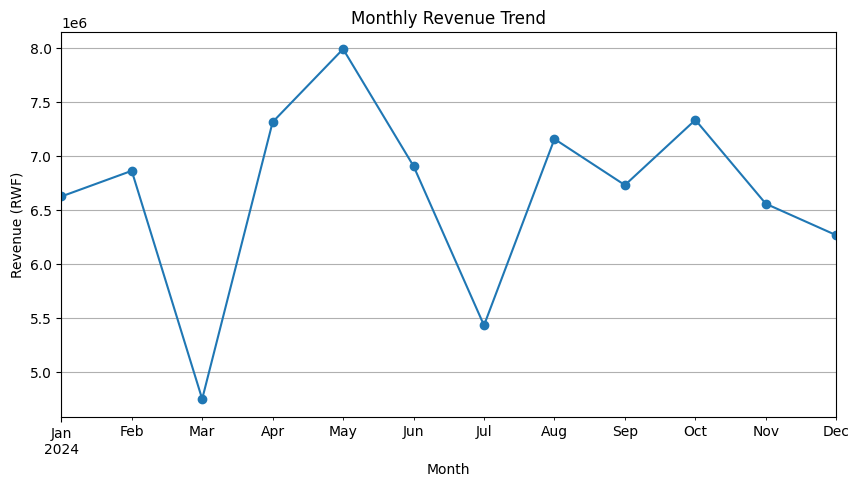

In [20]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (RWF)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

In [21]:
top_products = (
    df_clean
    .groupby("product_name")
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

top_products

,total_revenue,total_quantity
product_name,,
Creatine Monohydrate,14587106,635
Vitamins Complex,14456469,634
Whey Protein,14130669,624
Energy Extreme,12377101,556
PreWorkout X,12269888,557
Optimum Nutrition Creatine,12075420,533


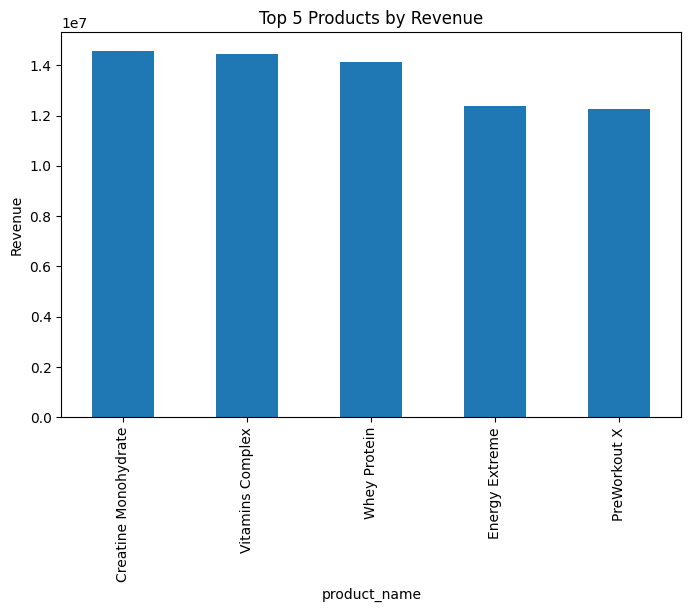

In [22]:
top_products.head(5)["total_revenue"].plot(kind="bar", figsize=(8,5))
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

In [23]:
revenue_by_city = (
    df_clean
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_city

city
Rwamagana    16655422
Rubavu       16633961
Musanze      16342507
Huye         15381535
Kigali       14883228
Name: revenue, dtype: int64

In [24]:
orders_per_customer = (
    df_clean
    .groupby("customer_id")["order_id"]
    .nunique()
)

orders_per_customer.describe()

count    388.000000
mean       3.664948
std        1.951904
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       13.000000
Name: order_id, dtype: float64

In [25]:
repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

repeat_customers, one_time_customers

(np.int64(344), np.int64(44))

In [26]:
category_performance = (
    df_clean
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_performance

category
Creatine       26662526
Vitamins       14456469
Whey           14130669
Energy         12377101
Pre-Workout    12269888
Name: revenue, dtype: int64

In [1]:
df = pd.read_csv("../data/processed/ecommerce_cleaned.csv")
df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/ecommerce_cleaned.csv")
df.head()

,order_id,order_date,customer_id,city,product_name,category,quantity,unit_price,revenue,payment_method
0,1,2024-04-12,96,Huye,Optimum Nutrition Creatine,Creatine,2,25775,51550,Bank Transfer
1,2,2024-12-14,302,Kigali,PreWorkout X,Pre-Workout,3,17206,51618,Card
2,3,2024-09-27,318,Musanze,Whey Protein,Whey,4,22316,89264,Cash
3,5,2024-03-12,239,Kigali,Optimum Nutrition Creatine,Creatine,4,28155,112620,Cash
4,6,2024-07-07,359,Rubavu,Energy Extreme,Energy,1,14361,14361,Card


In [3]:
import pandas as pd

snapshot_date = df_clean["order_date"].max() + pd.Timedelta(days=1)
snapshot_date

NameError: name 'df_clean' is not defined

In [5]:
df_clean = df.copy()

In [7]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], errors="coerce")

In [8]:
snapshot_date = df_clean["order_date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2024-12-31 00:00:00')

In [11]:
rfm = df_clean.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

rfm.head()

,customer_id,recency,frequency,monetary
0,1,141,2,156000
1,2,13,4,381433
2,3,73,5,218654
3,4,82,4,269824
4,5,6,4,187977


In [12]:
rfm.describe()

,customer_id,recency,frequency,monetary
count,388.000000,388.000000,388.000000,388.000000
mean,200.304124,88.997423,3.664948,205919.208763
std,115.671929,76.834851,1.951904,123098.074226
min,1.000000,1.000000,1.000000,20409.000000
25%,100.750000,27.000000,2.000000,115182.000000
50%,199.500000,67.500000,3.000000,178329.500000
75%,301.250000,131.500000,5.000000,277703.000000
max,399.000000,364.000000,13.000000,735750.000000


In [13]:
rfm["segment"] = "Regular"

# VIP customers
rfm.loc[
    (rfm["recency"] <= 30) &
    (rfm["frequency"] >= 5) &
    (rfm["monetary"] >= 100000),
    "segment"
] = "VIP"

# At Risk customers
rfm.loc[
    (rfm["recency"] > 90),
    "segment"
] = "At Risk"

In [14]:
rfm["segment"].value_counts()

segment
Regular    196
At Risk    155
VIP         37
Name: count, dtype: int64

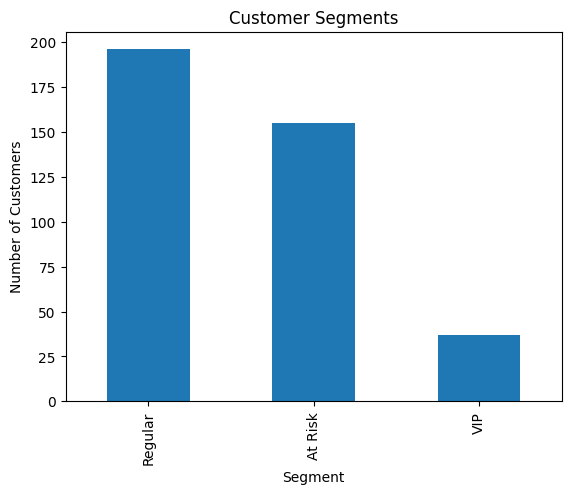

In [15]:
import matplotlib.pyplot as plt

rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
rfm.to_csv("../data/processed/rfm_table.csv", index=False)

In [18]:
top_products = (
    df_clean
    .groupby("product_name")
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

In [19]:
top_products.to_csv("../data/processed/top_products.csv")

In [20]:
total_revenue = df_clean["revenue"].sum()
total_orders = df_clean["order_id"].nunique()
total_customers = df_clean["customer_id"].nunique()
avg_order_value = total_revenue / total_orders

total_revenue, total_orders, total_customers, avg_order_value

(np.int64(79896653), 1422, 388, np.float64(56186.11322081575))

In [21]:
revenue_by_city.to_csv("../data/processed/revenue_by_city.csv")

NameError: name 'revenue_by_city' is not defined

In [22]:
revenue_by_city = (
    df_clean
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_city

city
Rwamagana    16655422
Rubavu       16633961
Musanze      16342507
Huye         15381535
Kigali       14883228
Name: revenue, dtype: int64

In [23]:
revenue_by_city.to_csv("../data/processed/revenue_by_city.csv")

In [24]:
monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (RWF)")
plt.xlabel("Month")
plt.grid(True)
plt.savefig("../reports/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

NameError: name 'monthly_revenue' is not defined

In [25]:
monthly_revenue = (
    df_clean
    .set_index("order_date")
    .resample("ME")["revenue"]
    .sum()
)

monthly_revenue

order_date
2024-01-31    6622436
2024-02-29    6860183
2024-03-31    4747766
2024-04-30    7311617
2024-05-31    7987579
2024-06-30    6903818
2024-07-31    5429736
2024-08-31    7154789
2024-09-30    6728066
2024-10-31    7331406
2024-11-30    6555171
2024-12-31    6264086
Freq: ME, Name: revenue, dtype: int64

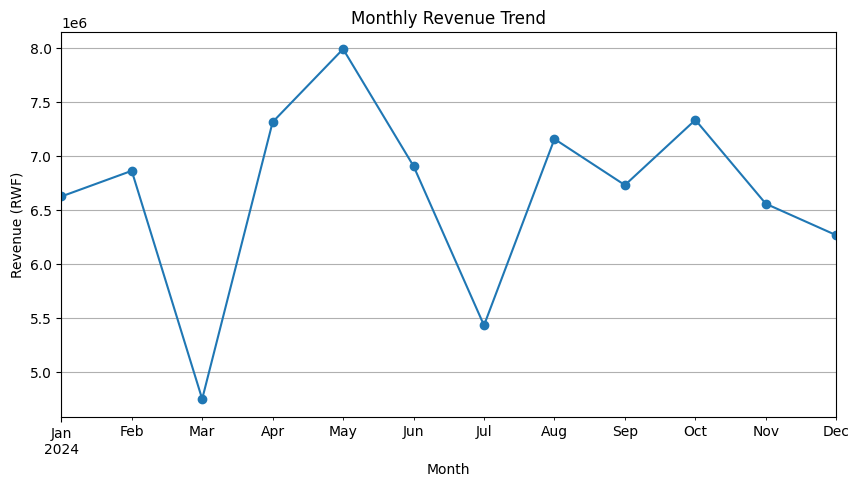

In [27]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (RWF)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

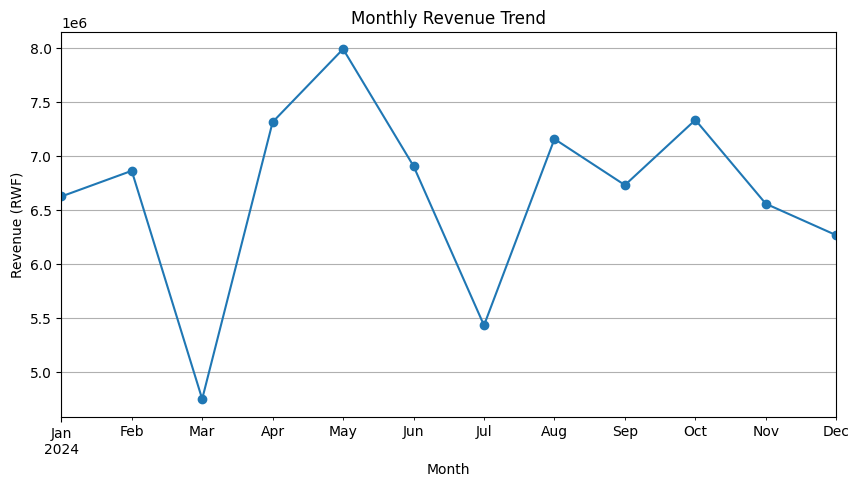

In [29]:
monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (RWF)")
plt.xlabel("Month")
plt.grid(True)
plt.savefig("../reports/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

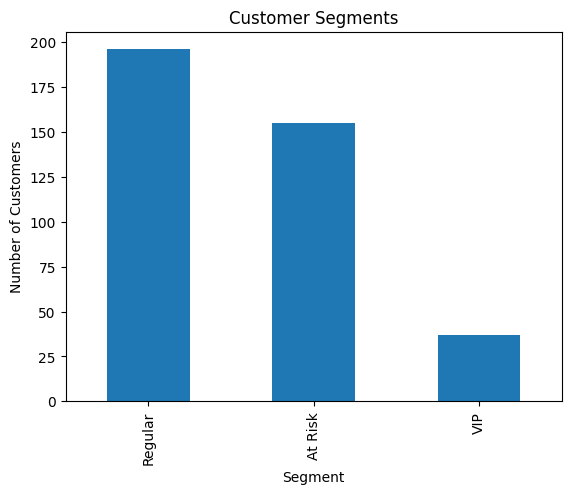

In [30]:
import matplotlib.pyplot as plt

rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

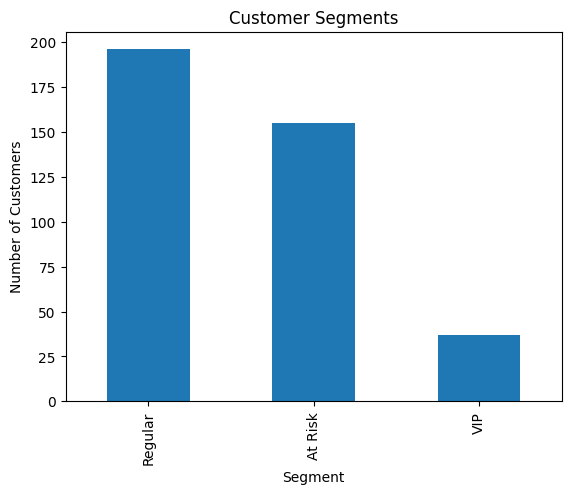

In [31]:
import matplotlib.pyplot as plt

rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.savefig("../reports/Customer_Segments.png", bbox_inches="tight")
plt.show()

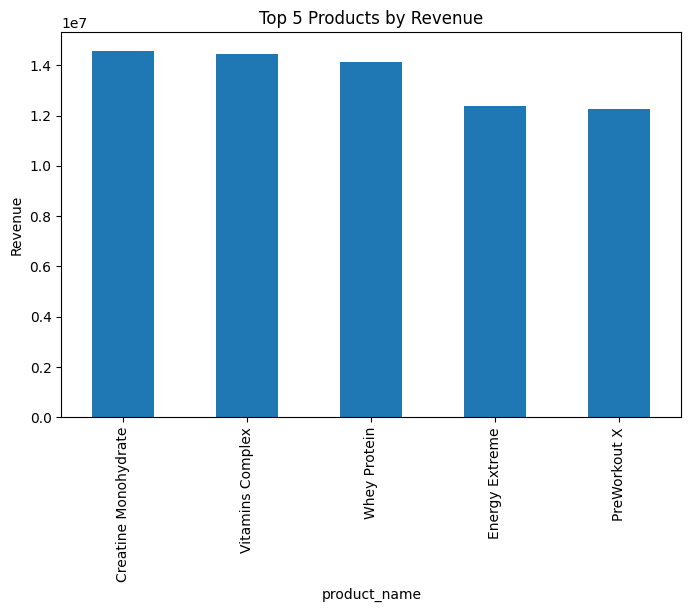

In [32]:
top_products.head(5)["total_revenue"].plot(kind="bar", figsize=(8,5))
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

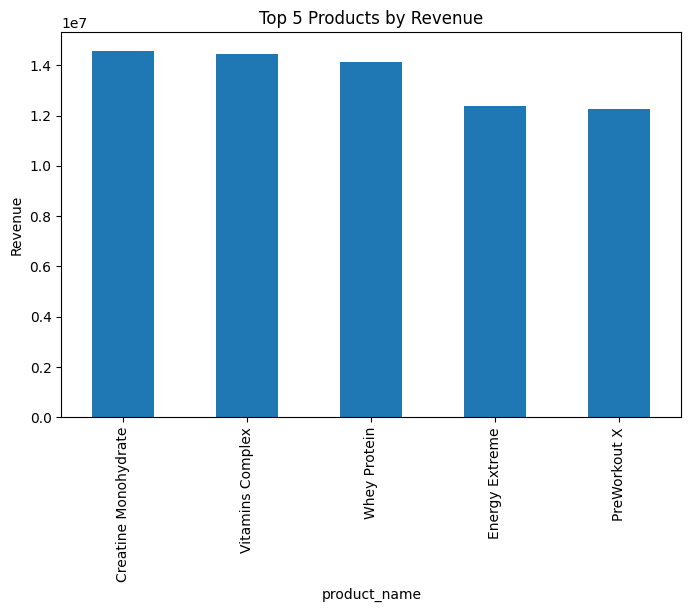

In [33]:
top_products.head(5)["total_revenue"].plot(kind="bar", figsize=(8,5))
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.savefig("../reports/Top_5_Product_by_Revenue.png", bbox_inches="tight")
plt.show()